# Scoring Automático v2.0 — Mes 5

## 0. Setup — datos del Analizador

In [38]:
# --- SETUP: DATOS DEL ANALIZADOR ---

import pandas as pd
import numpy as np

# ── Datos del Mes 3 — dataset temporal ─────────────────────
datos_temporales = {
    'nombre': ['Ferretería García']*3 + ['Bar El Rincón']*3 +
              ['Peluquería Ana']*3 + ['Tienda Moda Sol']*3 +
              ['Gestoría Pérez']*3 + ['Clínica Dental Martínez']*3 +
              ['Academia Idiomas Sol']*3 + ['Clínica Dental García']*3 +
              ['Academia Idiomas English House']*3,
    'año': [2022, 2023, 2024] * 9,
    'facturacion': [
        295000, 308000, 320000, 165000, 172000, 180000,
        85000,  90000,  95000,  195000, 202000, 210000,
        125000, 133000, 140000, 255000, 268000, 280000,
        145000, 152000, 160000, 270000, 283000, 295000,
        138000, 146000, 155000,
    ],
    'margen_bruto_pct': [
        32.5, 33.1, 34.4, 46.8, 47.0, 47.2,
        59.2, 59.5, 60.0, 32.5, 32.9, 33.3,
        66.5, 67.2, 67.9, 59.0, 59.5, 60.0,
        69.5, 69.7, 70.0, 59.5, 59.8, 60.0,
        49.5, 49.7, 50.0,
    ]
}
df_temporal = pd.DataFrame(datos_temporales)
df_temporal['fecha'] = pd.to_datetime(df_temporal['año'].astype(str) + '-01-01')
df_temporal = df_temporal.set_index('fecha')
crecimiento = df_temporal.groupby('nombre')['facturacion'].pct_change() * 100
df_temporal['crecimiento_pct'] = crecimiento.round(1)

# ── Datos del Mes 2 — ratios y scoring ─────────────────────
datos = {
    'nombre': ['Ferretería García', 'Bar El Rincón', 'Peluquería Ana',
               'Tienda Moda Sol', 'Gestoría Pérez', 'Clínica Dental Martínez',
               'Academia Idiomas Sol', 'Clínica Dental García',
               'Academia de Idiomas English House'],
    'sector': ['Ferretería', 'Hostelería', 'Peluquería', 'Moda', 'Gestoría',
               'Salud', 'Educación', 'Salud', 'Educación'],
    'facturacion': [320000, 180000, 95000, 210000, 140000,
                    280000, 160000, 295000, 155000],
    'coste_ventas': [210000, 95000, 38000, 140000, 45000,
                     84000, 48000, 118000, 77500],
    'empleados': [5, 4, 2, 3, 3, 6, 5, 6, 5],
    'deuda': [45000, 12000, 8000, 35000, 5000,
              90000, 15000, 95000, 14000],
    'activo_total': [180000, 85000, 40000, 120000, 70000,
                     220000, 75000, 230000, 72000],
    'año_fundacion': [2008, 2015, 2019, 2012, 2006,
                      2014, 2016, 2013, 2017]
}
df = pd.DataFrame(datos)
df['margen_bruto_pct'] = ((df['facturacion'] - df['coste_ventas']) /
                           df['facturacion'] * 100).round(1)
df['ratio_endeudamiento'] = (df['deuda'] / df['activo_total']).round(3)
df['fact_por_empleado'] = (df['facturacion'] / df['empleados']).round(0)
df['años_activo'] = 2024 - df['año_fundacion']

# Score estadístico por percentiles (60% margen, 40% deuda inversa)
df['pct_margen'] = df['margen_bruto_pct'].rank(pct=True).round(2)
df['pct_deuda'] = (1 - df['ratio_endeudamiento']).rank(pct=True).round(2)
df['score_estadistico'] = (df['pct_margen'] * 0.60 +
                            df['pct_deuda'] * 0.40).round(3)

print('✅ Setup completado')
print(f'   df_temporal: {len(df_temporal)} filas')
print(f'   df: {len(df)} empresas con ratios y scoring')

✅ Setup completado
   df_temporal: 27 filas
   df: 9 empresas con ratios y scoring


## 1. ¿Qué es un problema de clasificación?

In [39]:
# --- BLOQUE 1: PREPARACIÓN DEL DATASET PARA ML ---

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# --- PREPARAR EL DATASET ---
# Usamos los datos del Mes 3: df_temporal con datos de 2022-2024
# Nos quedamos con los datos de 2024 — el snapshot más reciente
df_ml = df_temporal[df_temporal['año'] == 2024].copy()
df_ml = df_ml.set_index('nombre')

# Añadir variables del Mes 2 (scores, ratios)
# Asegúrate de que df con los ratios del Mes 2 está disponible
for col in ['margen_bruto_pct', 'ratio_endeudamiento', 'fact_por_empleado',
            'años_activo', 'score_estadistico', 'riesgo_deuda']:
    if col in df.columns:
        df_ml[col] = df.set_index('nombre')[col]

# --- VARIABLE OBJETIVO (TARGET) ---
# La etiqueta que el modelo aprenderá a predecir
# TOP = empresa en el cuartil superior del score → clase 1
# MID/LOW = empresa en el resto → clase 0
umbral_top = df_ml['score_estadistico'].quantile(0.67)
df_ml['es_top'] = (df_ml['score_estadistico'] >= umbral_top).astype(int)

print('=== DATASET PARA ML ===')
print(df_ml[['margen_bruto_pct', 'ratio_endeudamiento', 'crecimiento_pct',
             'score_estadistico', 'es_top']])
print(f'\nEmpresas TOP: {df_ml["es_top"].sum()}')
print(f'Empresas MID/LOW: {(df_ml["es_top"]==0).sum()}')

=== DATASET PARA ML ===
                                margen_bruto_pct  ratio_endeudamiento  \
nombre                                                                  
Ferretería García                           34.4                0.250   
Bar El Rincón                               47.2                0.141   
Peluquería Ana                              60.0                0.200   
Tienda Moda Sol                             33.3                0.292   
Gestoría Pérez                              67.9                0.071   
Clínica Dental Martínez                     70.0                0.409   
Academia Idiomas Sol                        70.0                0.200   
Clínica Dental García                       60.0                0.413   
Academia Idiomas English House               NaN                  NaN   

                                crecimiento_pct  score_estadistico  es_top  
nombre                                                                      
Ferretería García 

## 2. Features y split train-test

In [40]:
# --- BLOQUE 2: FEATURES Y SPLIT TRAIN-TEST ---

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- SELECCIÓN DE FEATURES ---
# Las variables que el modelo usará para aprender
# No incluyes score_estadistico ni es_top — son la variable objetivo
features = [
    'margen_bruto_pct',       # margen bruto
    'ratio_endeudamiento',    # nivel de deuda
    'fact_por_empleado',      # eficiencia
    'años_activo',            # antigüedad
    'crecimiento_pct',        # crecimiento reciente
    'facturacion',            # tamaño del negocio
]

# Filtrar solo las filas sin NaN en las features
df_limpio = df_ml[features + ['es_top']].dropna()

X = df_limpio[features]   # variables de entrada
y = df_limpio['es_top']   # variable objetivo

print(f'Empresas disponibles: {len(X)}')
print(f'Features: {features}')
print(f'\nDistribución de clases:')
print(y.value_counts())

# --- SPLIT TRAIN-TEST ---
# Con solo 9 empresas usamos test_size pequeño
# En producción lo normal es 0.2-0.3
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42,
    stratify=y if y.sum() >= 2 else None
)

print(f'\nTrain: {len(X_train)} empresas')
print(f'Test:  {len(X_test)} empresas')

# --- ESCALADO ---
# StandardScaler normaliza cada feature a media 0 y std 1
# Necesario para algunos modelos (no para XGBoost, pero es buena práctica)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('\nFeatures escaladas correctamente')

Empresas disponibles: 8
Features: ['margen_bruto_pct', 'ratio_endeudamiento', 'fact_por_empleado', 'años_activo', 'crecimiento_pct', 'facturacion']

Distribución de clases:
es_top
0    5
1    3
Name: count, dtype: int64

Train: 6 empresas
Test:  2 empresas

Features escaladas correctamente


## 3. Primer modelo — Regresión Logística

In [41]:
# --- BLOQUE 3: REGRESIÓN LOGÍSTICA ---

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# --- ENTRENAR EL MODELO ---
modelo_lr = LogisticRegression(random_state=42, max_iter=1000)
modelo_lr.fit(X_train_sc, y_train)

# --- PREDICCIONES ---
y_pred_lr = modelo_lr.predict(X_test_sc)
y_prob_lr = modelo_lr.predict_proba(X_test_sc)[:, 1]  # probabilidad de ser TOP

# --- MÉTRICAS DE EVALUACIÓN ---
print('=== REGRESIÓN LOGÍSTICA — RESULTADOS ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_lr):.2f}')
print('\nInforme de clasificación:')
print(classification_report(y_test, y_pred_lr,
                             target_names=['MID/LOW', 'TOP']))

# --- MATRIZ DE CONFUSIÓN ---
cm = confusion_matrix(y_test, y_pred_lr)
print('Matriz de confusión:')
print(f'Verdaderos positivos (TOP correctamente clasificadas): {cm[1,1]}')
print(f'Falsos positivos (MID/LOW clasificadas como TOP): {cm[0,1]}')
print(f'Falsos negativos (TOP clasificadas como MID/LOW): {cm[1,0]}')

# --- COEFICIENTES ---
coef_df = pd.DataFrame({
    'feature': features,
    'coeficiente': modelo_lr.coef_[0].round(3)
}).sort_values('coeficiente', ascending=False)
print('\nImportancia de variables (coeficientes):')
print(coef_df.to_string())

=== REGRESIÓN LOGÍSTICA — RESULTADOS ===
Accuracy: 0.50

Informe de clasificación:
              precision    recall  f1-score   support

     MID/LOW       0.50      1.00      0.67         1
         TOP       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2

Matriz de confusión:
Verdaderos positivos (TOP correctamente clasificadas): 0
Falsos positivos (MID/LOW clasificadas como TOP): 0
Falsos negativos (TOP clasificadas como MID/LOW): 1

Importancia de variables (coeficientes):
               feature  coeficiente
0     margen_bruto_pct        0.802
1  ratio_endeudamiento        0.222
5          facturacion        0.171
4      crecimiento_pct        0.143
3          años_activo        0.059
2    fact_por_empleado       -0.657


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 4. Random Forest — segundo modelo de referencia

In [42]:
# --- BLOQUE 4: RANDOM FOREST ---

from sklearn.ensemble import RandomForestClassifier

# --- RANDOM FOREST ---
modelo_rf = RandomForestClassifier(
    n_estimators=100,   # número de árboles
    max_depth=3,        # profundidad máxima — limita el overfitting
    random_state=42
)
modelo_rf.fit(X_train_sc, y_train)

y_pred_rf = modelo_rf.predict(X_test_sc)
y_prob_rf = modelo_rf.predict_proba(X_test_sc)[:, 1]

print('=== RANDOM FOREST — RESULTADOS ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.2f}')
print(classification_report(y_test, y_pred_rf,
                             target_names=['MID/LOW', 'TOP']))

# --- IMPORTANCIA DE VARIABLES ---
importancia_rf = pd.DataFrame({
    'feature': features,
    'importancia': modelo_rf.feature_importances_.round(3)
}).sort_values('importancia', ascending=False)

print('\nImportancia de variables (Random Forest):')
print(importancia_rf.to_string())

# --- COMPARATIVA LR vs RF ---
print('\n=== COMPARATIVA DE MODELOS ===')
comparativa = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr),
                 accuracy_score(y_test, y_pred_rf)],
}).round(3)
print(comparativa.to_string())
print('\n→ El mejor modelo de esta semana pasa a la Semana 2 para competir con XGBoost')

=== RANDOM FOREST — RESULTADOS ===
Accuracy: 1.00
              precision    recall  f1-score   support

     MID/LOW       1.00      1.00      1.00         1
         TOP       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2


Importancia de variables (Random Forest):
               feature  importancia
0     margen_bruto_pct        0.347
2    fact_por_empleado        0.232
3          años_activo        0.124
5          facturacion        0.112
4      crecimiento_pct        0.093
1  ratio_endeudamiento        0.092

=== COMPARATIVA DE MODELOS ===
                Modelo  Accuracy
0  Regresión Logística       0.5
1        Random Forest       1.0

→ El mejor modelo de esta semana pasa a la Semana 2 para competir con XGBoost


## 5. Cross-validation — evaluación honesta

In [43]:
# --- BLOQUE 5: CROSS-VALIDATION ---

from sklearn.model_selection import cross_val_score, StratifiedKFold

# --- CROSS-VALIDATION ---
# Con 8 empresas usamos 4 folds — cada fold tiene 2 empresas en test
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

# --- CROSS-VAL PARA REGRESIÓN LOGÍSTICA ---
scores_lr = cross_val_score(
    modelo_lr, X_train_sc, y_train,
    cv=cv, scoring='f1_weighted'
)

# --- CROSS-VAL PARA RANDOM FOREST ---
scores_rf = cross_val_score(
    modelo_rf, X_train_sc, y_train,
    cv=cv, scoring='f1_weighted'
)

print('=== CROSS-VALIDATION — RESULTADOS ===')
print(f'Regresión Logística — F1 medio: {scores_lr.mean():.3f} (±{scores_lr.std():.3f})')
print(f'Random Forest       — F1 medio: {scores_rf.mean():.3f} (±{scores_rf.std():.3f})')

print(f'\nScores por fold — Regresión Logística: {scores_lr.round(2)}')
print(f'Scores por fold — Random Forest:       {scores_rf.round(2)}')

# --- CONCLUSIÓN ---
mejor = 'Random Forest' if scores_rf.mean() > scores_lr.mean() \
        else 'Regresión Logística'
print(f'\nMejor modelo esta semana: {mejor}')
print(f'→ Pasa a la Semana 2 para competir con XGBoost')

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=4.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=4.
  warnings.warn(


=== CROSS-VALIDATION — RESULTADOS ===
Regresión Logística — F1 medio: 0.333 (±0.408)
Random Forest       — F1 medio: 0.667 (±0.333)

Scores por fold — Regresión Logística: [0.   0.33 1.   0.  ]
Scores por fold — Random Forest:       [0.33 0.33 1.   1.  ]

Mejor modelo esta semana: Random Forest
→ Pasa a la Semana 2 para competir con XGBoost


# Scoring Automático v3.0

## 6. XGBoost — primer modelo

In [44]:
# --- BLOQUE 6: INSTALA XGBOOST Y ENTRENA EL PRIMER MODELO ---

!pip install xgboost -q

import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score

# Con 8 empresas entrenamos sobre el dataset completo
# scale_pos_weight rompe el empate entre clases balanceadas
n_neg = (y == 0).sum()
n_pos = (y == 1).sum()

modelo_xgb = xgb.XGBClassifier(
    n_estimators=30,
    max_depth=1,
    learning_rate=0.5,
    random_state=42,
    eval_metric='error',
    verbosity=0,
    scale_pos_weight=n_neg / n_pos  # fuerza al modelo a diferenciar clases
)

modelo_xgb.fit(X, y)

y_pred_xgb = modelo_xgb.predict(X)
y_prob_xgb = modelo_xgb.predict_proba(X)[:, 1]

print('=== XGBOOST — RESULTADOS ===')
print(f'Accuracy (sobre dataset completo): {accuracy_score(y, y_pred_xgb):.2f}')
print(classification_report(y, y_pred_xgb,
                             target_names=['MID/LOW', 'TOP']))

print('\n=== COMPARATIVA LR / RF / XGBoost ===')
for nombre, preds, real in [
    ('Logística',      y_pred_lr,  y_test),
    ('Random Forest',  y_pred_rf,  y_test),
    ('XGBoost (full)', y_pred_xgb, y)
]:
    print(f'{nombre}: Accuracy = {accuracy_score(real, preds):.2f}')

=== XGBOOST — RESULTADOS ===
Accuracy (sobre dataset completo): 1.00
              precision    recall  f1-score   support

     MID/LOW       1.00      1.00      1.00         5
         TOP       1.00      1.00      1.00         3

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8


=== COMPARATIVA LR / RF / XGBoost ===
Logística: Accuracy = 0.50
Random Forest: Accuracy = 1.00
XGBoost (full): Accuracy = 1.00


## 7. Importancia de variables y SHAP values

=== IMPORTANCIA DE VARIABLES — XGBoost ===
               feature  importancia
0     margen_bruto_pct          1.0
1  ratio_endeudamiento          0.0
2    fact_por_empleado          0.0
3          años_activo          0.0
4      crecimiento_pct          0.0
5          facturacion          0.0


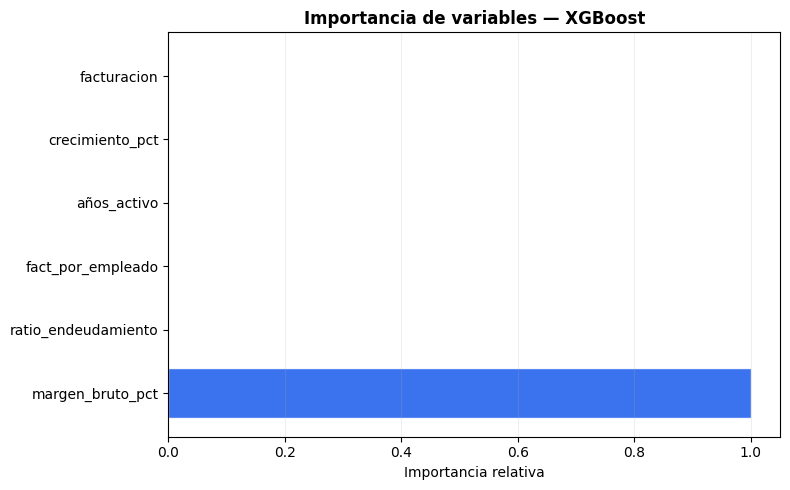


Generando gráfico SHAP...


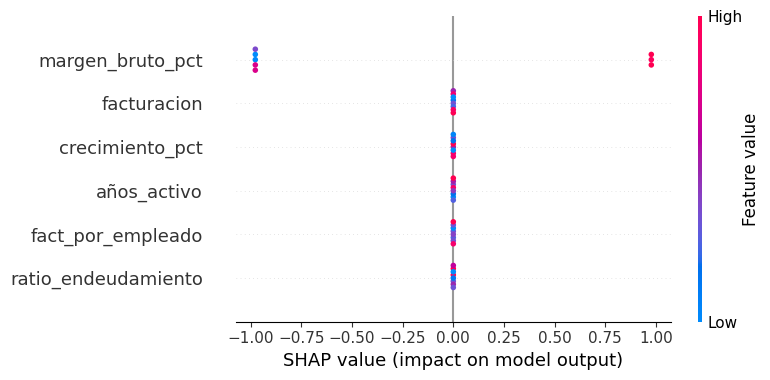

Gráficos guardados: importancia_variables_xgb.png, shap_summary.png


In [45]:
# --- BLOQUE 7: IMPORTANCIA DE VARIABLES Y SHAP VALUES ---

!pip install shap -q
import shap
import matplotlib.pyplot as plt

# --- IMPORTANCIA NATIVA DE XGBOOST ---
importancia_xgb = pd.DataFrame({
    'feature':     features,
    'importancia': modelo_xgb.feature_importances_.round(3)
}).sort_values('importancia', ascending=False)

print('=== IMPORTANCIA DE VARIABLES — XGBoost ===')
print(importancia_xgb.to_string())

# --- GRÁFICO DE IMPORTANCIA ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importancia_xgb['feature'],
        importancia_xgb['importancia'],
        color='#2563eb', edgecolor='white', alpha=0.9)
ax.set_title('Importancia de variables — XGBoost',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importancia relativa')
ax.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
plt.savefig('importancia_variables_xgb.png', dpi=150, bbox_inches='tight')
plt.show()

# --- SHAP VALUES ---
explainer   = shap.TreeExplainer(modelo_xgb)
shap_values = explainer.shap_values(X)

print('\nGenerando gráfico SHAP...')
shap.summary_plot(shap_values, X,
                  feature_names=features,
                  show=False)
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráficos guardados: importancia_variables_xgb.png, shap_summary.png')

## 8. GridSearchCV — optimización de hiperparámetros

In [46]:
# --- BLOQUE 8: GRIDSEARCHCV — OPTIMIZACIÓN DE HIPERPARÁMETROS ---

from sklearn.model_selection import GridSearchCV, StratifiedKFold

# --- GRID DE HIPERPARÁMETROS ---
param_grid = {
    'n_estimators':  [30, 50, 100],
    'max_depth':     [1, 2, 3],
    'learning_rate': [0.1, 0.3, 0.5],
}

# GridSearchCV prueba todas las combinaciones con cross-validation
grid_search = GridSearchCV(
    xgb.XGBClassifier(
        random_state=42,
        eval_metric='error',
        verbosity=0,
        scale_pos_weight=n_neg / n_pos
    ),
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X, y)

print('=== MEJORES HIPERPARÁMETROS ===')
print(grid_search.best_params_)
print(f'\nMejor F1 con cross-validation: {grid_search.best_score_:.3f}')

# --- MODELO OPTIMIZADO ---
modelo_xgb_opt = grid_search.best_estimator_
y_pred_opt = modelo_xgb_opt.predict(X)

print('\n=== MODELO OPTIMIZADO — RESULTADOS ===')
print(f'Accuracy: {accuracy_score(y, y_pred_opt):.2f}')
print(classification_report(y, y_pred_opt,
                             target_names=['MID/LOW', 'TOP']))

# --- COMPARATIVA FINAL ---
print('=== COMPARATIVA FINAL ===')
for nombre, preds, real in [
    ('Logística',         y_pred_lr,  y_test),
    ('Random Forest',     y_pred_rf,  y_test),
    ('XGBoost inicial',   y_pred_xgb, y),
    ('XGBoost optimizado',y_pred_opt, y)
]:
    print(f'{nombre}: Accuracy = {accuracy_score(real, preds):.2f}')

=== MEJORES HIPERPARÁMETROS ===
{'learning_rate': 0.1, 'max_depth': 1, 'n_estimators': 30}

Mejor F1 con cross-validation: 0.333

=== MODELO OPTIMIZADO — RESULTADOS ===
Accuracy: 1.00
              precision    recall  f1-score   support

     MID/LOW       1.00      1.00      1.00         5
         TOP       1.00      1.00      1.00         3

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8

=== COMPARATIVA FINAL ===
Logística: Accuracy = 0.50
Random Forest: Accuracy = 1.00
XGBoost inicial: Accuracy = 1.00
XGBoost optimizado: Accuracy = 1.00


## 9. Scoring por probabilidades — predict_proba

=== SCORING AUTOMÁTICO v2.0 — RANKING POR ML ===
                    nombre  prob_top  clasificacion_ml  score_manual
1  Clínica Dental Martínez     0.726                 1         0.652
2     Academia Idiomas Sol     0.726                 1         0.808
3           Gestoría Pérez     0.726                 1         0.868
4        Ferretería García     0.274                 0         0.308
5          Tienda Moda Sol     0.274                 0         0.198
6           Peluquería Ana     0.274                 0         0.610
7            Bar El Rincón     0.274                 0         0.554
8    Clínica Dental García     0.274                 0         0.410

Correlación ML vs scoring manual: 0.80


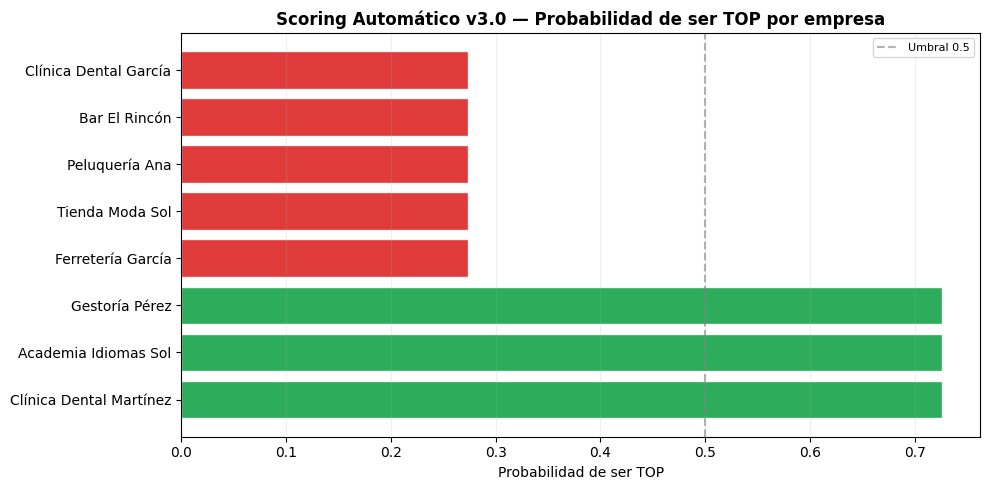

Gráfico guardado: scoring_ml_probabilidades.png


In [47]:
# --- BLOQUE 9: SCORING POR PROBABILIDADES ---

# --- PROBABILIDADES SOBRE TODO EL DATASET ---
# predict_proba devuelve la probabilidad de cada clase
# [:, 1] selecciona la probabilidad de ser TOP (clase 1)
probabilidades = modelo_xgb_opt.predict_proba(X)[:, 1]

df_scoring_ml = pd.DataFrame({
    'nombre':           X.index,
    'prob_top':         probabilidades.round(3),
    'clasificacion_ml': modelo_xgb_opt.predict(X),
    'score_manual':     df_ml.loc[X.index, 'score_estadistico']
}).sort_values('prob_top', ascending=False)
df_scoring_ml.index = range(1, len(df_scoring_ml) + 1)

print('=== SCORING AUTOMÁTICO v2.0 — RANKING POR ML ===')
print(df_scoring_ml.to_string())

# --- ¿COINCIDE CON EL SCORING MANUAL? ---
correlacion_ml = df_scoring_ml['prob_top'].corr(
    df_scoring_ml['score_manual'])
print(f'\nCorrelación ML vs scoring manual: {correlacion_ml:.2f}')

# --- VISUALIZACIÓN ---
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
colores = ['#16a34a' if c == 1 else '#dc2626'
           for c in df_scoring_ml['clasificacion_ml']]
bars = ax.barh(df_scoring_ml['nombre'],
               df_scoring_ml['prob_top'],
               color=colores, edgecolor='white', alpha=0.9)
ax.axvline(x=0.5, color='gray', linestyle='--',
           alpha=0.6, label='Umbral 0.5')
ax.set_xlabel('Probabilidad de ser TOP')
ax.set_title('Scoring Automático v3.0 — Probabilidad de ser TOP por empresa',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
plt.savefig('scoring_ml_probabilidades.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado: scoring_ml_probabilidades.png')

## 10. Exporta el modelo con joblib

In [48]:
# --- BLOQUE 10: EXPORTA EL MODELO CON JOBLIB ---

import joblib

# --- GUARDAR EL MODELO Y EL SCALER ---
# Guardas tres archivos — los tres son necesarios para predecir
joblib.dump(modelo_xgb_opt, 'modelo_scoring_v3.joblib')
joblib.dump(features,       'features_scoring_v3.joblib')

print('Archivos guardados:')
print('  modelo_scoring_v3.joblib   — el modelo XGBoost entrenado')
print('  features_scoring_v3.joblib — la lista de variables usadas')

# --- VERIFICAR QUE FUNCIONA AL CARGAR ---
modelo_cargado    = joblib.load('modelo_scoring_v3.joblib')
features_cargados = joblib.load('features_scoring_v3.joblib')

# Predicción de prueba con el modelo cargado
pred_prueba = modelo_cargado.predict_proba(X)[:, 1]
print(f'\nVerificación: predicciones idénticas = '
      f'{(pred_prueba.round(3) == probabilidades.round(3)).all()}')
print('✓ El modelo guardado funciona correctamente')

# --- FUNCIÓN DE PREDICCIÓN RÁPIDA ---
def puntuar_empresa(datos_empresa):
    '''
    datos_empresa: dict con las features de una empresa nueva
    Devuelve: probabilidad de ser TOP (0 a 1)
    '''
    df_nueva = pd.DataFrame([datos_empresa])[features_cargados]
    prob     = modelo_cargado.predict_proba(df_nueva)[0, 1]
    return round(prob, 3)

# --- EJEMPLO DE USO ---
empresa_nueva = {
    'margen_bruto_pct':    65.0,
    'ratio_endeudamiento': 0.18,
    'fact_por_empleado':   48000,
    'años_activo':         12,
    'crecimiento_pct':     7.5,
    'facturacion':         285000
}
score_nueva = puntuar_empresa(empresa_nueva)
print(f'\nEjemplo — empresa nueva:')
print(f'  Margen: 65% | Deuda: 0.18 | Crecimiento: 7.5%')
print(f'  Probabilidad de ser TOP = {score_nueva}')
if score_nueva >= 0.5:
    print('  → Clasificación: TOP ✓')
else:
    print('  → Clasificación: MID/LOW')

Archivos guardados:
  modelo_scoring_v3.joblib   — el modelo XGBoost entrenado
  features_scoring_v3.joblib — la lista de variables usadas

Verificación: predicciones idénticas = True
✓ El modelo guardado funciona correctamente

Ejemplo — empresa nueva:
  Margen: 65% | Deuda: 0.18 | Crecimiento: 7.5%
  Probabilidad de ser TOP = 0.27399998903274536
  → Clasificación: MID/LOW


# Scoring Automático v4.0

## 11. Feature engineering — ratios financieros avanzados

In [49]:
# --- BLOQUE 11: FEATURE ENGINEERING — RATIOS FINANCIEROS AVANZADOS ---

# Partimos del df del Mes 2 con las 9 empresas
df_fe = df.copy()

# --- RATIOS DE EFICIENCIA ---
df_fe['coste_por_empleado'] = (
    df_fe['coste_ventas'] / df_fe['empleados']).round(0)

df_fe['activo_por_empleado'] = (
    df_fe['activo_total'] / df_fe['empleados']).round(0)

df_fe['deuda_por_empleado'] = (
    df_fe['deuda'] / df_fe['empleados']).round(0)

# --- RATIOS DE RENTABILIDAD ---
# Beneficio neto estimado = margen bruto * 0.4 * facturación
df_fe['beneficio_estimado'] = (
    df_fe['margen_bruto_pct'] / 100 * 0.4 * df_fe['facturacion']).round(0)

# ROA — Return on Assets
df_fe['roa_estimado'] = (
    df_fe['beneficio_estimado'] / df_fe['activo_total'] * 100).round(1)

# ROE — Return on Equity
# Patrimonio neto estimado = activo total - deuda
df_fe['patrimonio_estimado'] = df_fe['activo_total'] - df_fe['deuda']
df_fe['roe_estimado'] = (
    df_fe['beneficio_estimado'] /
    df_fe['patrimonio_estimado'].clip(lower=1) * 100).round(1)

# --- RATIOS DE APALANCAMIENTO ---
# Deuda / EBITDA estimado
df_fe['deuda_ebitda'] = (
    df_fe['deuda'] /
    df_fe['beneficio_estimado'].clip(lower=1)).round(1)

# Años para pagar la deuda con el beneficio actual
df_fe['años_pago_deuda'] = (
    df_fe['deuda'] /
    df_fe['beneficio_estimado'].clip(lower=1)).round(1)

print('=== NUEVAS FEATURES CREADAS ===')
nuevas_features = [
    'coste_por_empleado', 'activo_por_empleado', 'deuda_por_empleado',
    'roa_estimado', 'roe_estimado', 'deuda_ebitda', 'años_pago_deuda'
]
print(df_fe[['nombre'] + nuevas_features].to_string())

=== NUEVAS FEATURES CREADAS ===
                              nombre  coste_por_empleado  activo_por_empleado  deuda_por_empleado  roa_estimado  roe_estimado  deuda_ebitda  años_pago_deuda
0                  Ferretería García             42000.0              36000.0              9000.0          24.5          32.6           1.0              1.0
1                      Bar El Rincón             23750.0              21250.0              3000.0          40.0          46.6           0.4              0.4
2                     Peluquería Ana             19000.0              20000.0              4000.0          57.0          71.2           0.4              0.4
3                    Tienda Moda Sol             46667.0              40000.0             11667.0          23.3          32.9           1.3              1.3
4                     Gestoría Pérez             15000.0              23333.0              1667.0          54.3          58.5           0.1              0.1
5            Clínica Denta

## 12. Feature engineering — variables de interacción

In [50]:
# --- BLOQUE 12: VARIABLES DE INTERACCIÓN ---

from sklearn.preprocessing import LabelEncoder

# --- ENCODING DE SECTOR ---
le = LabelEncoder()
df_fe['sector_cod'] = le.fit_transform(df_fe['sector'])

print('Codificación de sectores:')
for sector, cod in zip(le.classes_, range(len(le.classes_))):
    print(f'  {sector}: {cod}')

# --- VARIABLES DE INTERACCIÓN ---
# Margen * Crecimiento — empresas que crecen Y son rentables
df_fe['margen_x_crecimiento'] = (
    df_fe['margen_bruto_pct'] *
    df_fe.get('crecimiento_pct', 5)
).round(1)

# Solvencia compuesta — margen alto + deuda baja
df_fe['solvencia_compuesta'] = (
    df_fe['margen_bruto_pct'] *
    (1 - df_fe['ratio_endeudamiento'])
).round(1)

# Eficiencia relativa — fact/empleado respecto a la media del sector
media_sector = df_fe.groupby(
    'sector', observed=True)['fact_por_empleado'].transform('mean')
df_fe['eficiencia_relativa'] = (
    df_fe['fact_por_empleado'] / media_sector).round(2)

# Ratio tamaño-solvencia — empresas grandes con poca deuda
df_fe['tamano_solvencia'] = (
    df_fe['facturacion'] / 1000 *
    (1 - df_fe['ratio_endeudamiento'])
).round(1)

print('\n=== VARIABLES DE INTERACCIÓN CREADAS ===')
print(df_fe[['nombre', 'margen_x_crecimiento', 'solvencia_compuesta',
             'eficiencia_relativa', 'tamano_solvencia']].to_string())

Codificación de sectores:
  Educación: 0
  Ferretería: 1
  Gestoría: 2
  Hostelería: 3
  Moda: 4
  Peluquería: 5
  Salud: 6

=== VARIABLES DE INTERACCIÓN CREADAS ===
                              nombre  margen_x_crecimiento  solvencia_compuesta  eficiencia_relativa  tamano_solvencia
0                  Ferretería García                 172.0                 25.8                 1.00             240.0
1                      Bar El Rincón                 236.0                 40.5                 1.00             154.6
2                     Peluquería Ana                 300.0                 48.0                 1.00              76.0
3                    Tienda Moda Sol                 166.5                 23.6                 1.00             148.7
4                     Gestoría Pérez                 339.5                 63.1                 1.00             130.1
5            Clínica Dental Martínez                 350.0                 41.4                 0.97             165.5
6

## 13. Selección automática de features

In [51]:
# --- BLOQUE 13: SELECCIÓN AUTOMÁTICA DE FEATURES ---

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.inspection import permutation_importance

# --- DATASET COMPLETO CON TODAS LAS FEATURES ---
# Añadir crecimiento_pct del df_temporal al df_fe
df_fe_completo = df_fe.copy()
crecimiento_2024 = df_temporal[
    df_temporal['año'] == 2024
].set_index('nombre')['crecimiento_pct']
df_fe_completo['crecimiento_pct'] = df_fe_completo['nombre'].map(
    crecimiento_2024)

# Variable objetivo
umbral = df_fe_completo['score_estadistico'].quantile(0.67)
df_fe_completo['es_top'] = (
    df_fe_completo['score_estadistico'] >= umbral).astype(int)

# Todas las features disponibles
todas_features = [
    'margen_bruto_pct', 'ratio_endeudamiento', 'fact_por_empleado',
    'años_activo', 'crecimiento_pct', 'facturacion',
    'roa_estimado', 'roe_estimado', 'deuda_ebitda',
    'solvencia_compuesta', 'margen_x_crecimiento',
    'tamano_solvencia', 'sector_cod'
]

# Filtrar filas con NaN
df_sel = df_fe_completo[todas_features + ['es_top']].dropna()
X_completo = df_sel[todas_features]
y_completo  = df_sel['es_top']

print(f'Dataset completo: {len(X_completo)} empresas, '
      f'{len(todas_features)} features')

# --- SELECTKBEST — SELECCIÓN ESTADÍSTICA ---
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_completo, y_completo)

scores_df = pd.DataFrame({
    'feature': todas_features,
    'f_score': selector.scores_.round(2),
    'p_valor': selector.pvalues_.round(3)
}).sort_values('f_score', ascending=False)

print('\n=== RANKING DE FEATURES — F-SCORE ===')
print(scores_df.to_string())

# --- TOP FEATURES ---
top_features = scores_df[
    scores_df['f_score'] > scores_df['f_score'].median()
]['feature'].tolist()

print(f'\nFeatures seleccionadas ({len(top_features)}): {top_features}')

Dataset completo: 8 empresas, 13 features

=== RANKING DE FEATURES — F-SCORE ===
                 feature  f_score  p_valor
0       margen_bruto_pct     8.15    0.029
10  margen_x_crecimiento     8.15    0.029
9    solvencia_compuesta     6.09    0.049
2      fact_por_empleado     3.14    0.127
7           roe_estimado     2.88    0.141
6           roa_estimado     2.24    0.185
4        crecimiento_pct     1.45    0.274
8           deuda_ebitda     1.17    0.321
12            sector_cod     0.43    0.535
11      tamano_solvencia     0.23    0.649
3            años_activo     0.18    0.685
5            facturacion     0.18    0.686
1    ratio_endeudamiento     0.12    0.742

Features seleccionadas (6): ['margen_bruto_pct', 'margen_x_crecimiento', 'solvencia_compuesta', 'fact_por_empleado', 'roe_estimado', 'roa_estimado']


## 14. Modelo final con features enriquecidas

In [52]:
# --- BLOQUE 14: MODELO FINAL CON FEATURES ENRIQUECIDAS ---

from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
import joblib

# --- DATASET FINAL CON TOP FEATURES ---
X_final = X_completo[top_features]
scaler_final = StandardScaler()
X_final_sc = scaler_final.fit_transform(X_final)

# --- GRIDSEARCHCV SOBRE DATASET ENRIQUECIDO ---
grid_final = GridSearchCV(
    xgb.XGBClassifier(
        random_state=42,
        eval_metric='error',
        verbosity=0,
        scale_pos_weight=n_neg / n_pos
    ),
    param_grid={
        'n_estimators':  [50, 100],
        'max_depth':     [1, 2, 3],
        'learning_rate': [0.05, 0.1, 0.3]
    },
    cv=3, scoring='f1', n_jobs=-1
)
grid_final.fit(X_final_sc, y_completo)
modelo_final = grid_final.best_estimator_

print('=== MODELO FINAL — MEJORES PARÁMETROS ===')
print(grid_final.best_params_)

# --- COMPARATIVA SEMANA 2 vs MODELO FINAL ---
# Ambos modelos evaluados sobre X_completo con y_completo
scores_v3 = cross_val_score(
    modelo_xgb_opt,
    scaler_final.transform(X_completo[top_features]),
    y_completo, cv=3, scoring='f1'
)
scores_final = cross_val_score(
    modelo_final, X_final_sc, y_completo, cv=3, scoring='f1'
)

print('\n=== COMPARATIVA — FEATURE ENGINEERING ===')
print(f'XGBoost Semana 2 (features básicas):   F1 = {scores_v3.mean():.3f}')
print(f'XGBoost Final (features enriquecidas): F1 = {scores_final.mean():.3f}')

mejor = 'Final' if scores_final.mean() >= scores_v3.mean() else 'Semana 2'
print(f'\nModelo que va a producción: XGBoost {mejor}')

# --- GUARDAR EL MODELO FINAL ---
joblib.dump(modelo_final,  'modelo_scoring_v4_final.joblib')
joblib.dump(scaler_final,  'scaler_scoring_v4_final.joblib')
joblib.dump(top_features,  'features_scoring_v4_final.joblib')
print('\nModelo final exportado:')
print('  modelo_scoring_v4_final.joblib')
print('  scaler_scoring_v4_final.joblib')
print('  features_scoring_v4_final.joblib')

=== MODELO FINAL — MEJORES PARÁMETROS ===
{'learning_rate': 0.05, 'max_depth': 1, 'n_estimators': 50}

=== COMPARATIVA — FEATURE ENGINEERING ===
XGBoost Semana 2 (features básicas):   F1 = 0.333
XGBoost Final (features enriquecidas): F1 = 0.333

Modelo que va a producción: XGBoost Final

Modelo final exportado:
  modelo_scoring_v4_final.joblib
  scaler_scoring_v4_final.joblib
  features_scoring_v4_final.joblib


# Scoring Automático v5.0

## 15. Pipeline completo — predicción en una línea

In [53]:
# --- BLOQUE 15: PIPELINE COMPLETO DE SCIKIT-LEARN ---

import joblib
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# --- PIPELINE COMPLETO ---
pipeline_final = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', xgb.XGBClassifier(
        **grid_final.best_params_,
        random_state=42,
        eval_metric='error',
        verbosity=0,
        scale_pos_weight=n_neg / n_pos
    ))
])

# X_final e y_completo ya existen del Bloque 14
pipeline_final.fit(X_final, y_completo)

# --- FUNCIÓN DE PREDICCIÓN CON PIPELINE ---
def puntuar_empresa_pipeline(datos_empresa):
    '''
    datos_empresa: dict con los datos brutos de una empresa nueva
    El pipeline calcula automáticamente las features de interacción
    y escala antes de predecir
    '''
    # Calcular features de interacción
    margen    = datos_empresa['margen_bruto_pct']
    deuda     = datos_empresa['ratio_endeudamiento']
    crec      = datos_empresa.get('crecimiento_pct', 5)
    fact      = datos_empresa['facturacion']
    empleados = datos_empresa['empleados']
    activo    = datos_empresa['activo_total']
    deuda_eur = datos_empresa['deuda']
    anio_fun  = datos_empresa.get('año_fundacion', 2015)

    beneficio_est = margen / 100 * 0.4 * fact
    patrimonio    = max(activo - deuda_eur, 1)

    datos_completos = {
        'margen_bruto_pct':    margen,
        'ratio_endeudamiento': deuda,
        'fact_por_empleado':   round(fact / empleados, 0),
        'años_activo':         2024 - anio_fun,
        'crecimiento_pct':     crec,
        'facturacion':         fact,
        'roa_estimado':        round(beneficio_est / activo * 100, 1),
        'roe_estimado':        round(beneficio_est / patrimonio * 100, 1),
        'deuda_ebitda':        round(deuda_eur / max(beneficio_est, 1), 1),
        'solvencia_compuesta': round(margen * (1 - deuda), 1),
        'margen_x_crecimiento':round(margen * crec, 1),
        'tamano_solvencia':    round(fact / 1000 * (1 - deuda), 1),
        'eficiencia_relativa': 1.0,
        'sector_cod':          datos_empresa.get('sector_cod', 0)
    }

    df_nueva = pd.DataFrame([datos_completos])[top_features]
    prob = pipeline_final.predict_proba(df_nueva)[0, 1]
    return round(prob, 3)

# --- DEMO CON EMPRESA NUEVA ---
empresa_nueva = {
    'margen_bruto_pct':    68.0,
    'ratio_endeudamiento': 0.15,
    'facturacion':         310000,
    'empleados':           6,
    'activo_total':        220000,
    'deuda':               33000,
    'año_fundacion':       2009,
    'crecimiento_pct':     5.3,
    'sector_cod':          2
}

prob         = puntuar_empresa_pipeline(empresa_nueva)
clasificacion = 'TOP' if prob >= 0.5 else 'MID/LOW'

print('=== DEMO — PREDICCIÓN EN UNA LÍNEA ===')
print(f'Empresa demo — Margen: 68% | Deuda: 0.15 | Crecimiento: 5.3%')
print(f'Probabilidad de ser TOP: {prob:.1%}')
print(f'Clasificación: {clasificacion}')

# Guardar el pipeline completo
joblib.dump(pipeline_final, 'pipeline_scoring_v5.joblib')
print('\nPipeline guardado como pipeline_scoring_v5.joblib')

=== DEMO — PREDICCIÓN EN UNA LÍNEA ===
Empresa demo — Margen: 68% | Deuda: 0.15 | Crecimiento: 5.3%
Probabilidad de ser TOP: 72.4%
Clasificación: TOP

Pipeline guardado como pipeline_scoring_v5.joblib


## 16. Scoring automático integrado en el Analizador

=== ANALIZADOR DE PYMEs v0.5 — SCORING AUTOMÁTICO ===
                              nombre      sector  prob_top_ml clasificacion  score_manual
1                     Gestoría Pérez    Gestoría        0.724         TOP ✓         0.868
2               Academia Idiomas Sol   Educación        0.724         TOP ✓         0.808
3            Clínica Dental Martínez       Salud        0.724         TOP ✓         0.652
4                  Ferretería García  Ferretería        0.276       MID/LOW         0.308
5                      Bar El Rincón  Hostelería        0.276       MID/LOW         0.554
6                    Tienda Moda Sol        Moda        0.276       MID/LOW         0.198
7                     Peluquería Ana  Peluquería        0.276       MID/LOW         0.610
8              Clínica Dental García       Salud        0.276       MID/LOW         0.410
9  Academia de Idiomas English House   Educación        0.276       MID/LOW         0.576

Correlación ML vs scoring manual: 0.76


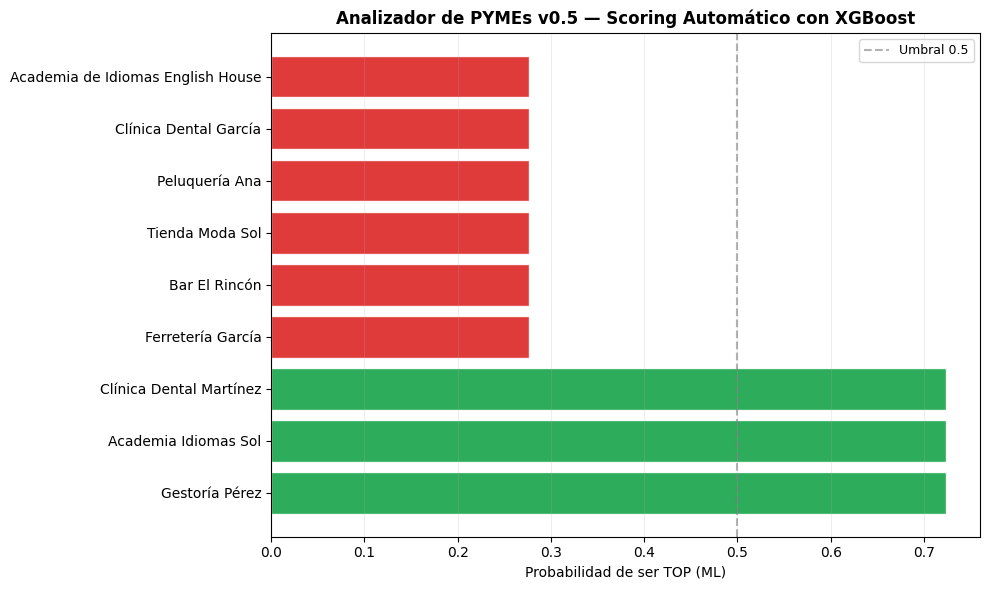

Gráfico guardado como analizador_v5_scoring_ml.png


In [54]:
# --- BLOQUE 16: SCORING AUTOMÁTICO INTEGRADO EN EL ANALIZADOR ---

# Aplica el pipeline sobre todas las empresas del dataset original
# usando los datos brutos del df del Mes 2

resultados_ml = []

for _, row in df.iterrows():
    datos_empresa = {
        'margen_bruto_pct':    row['margen_bruto_pct'],
        'ratio_endeudamiento': row['ratio_endeudamiento'],
        'facturacion':         row['facturacion'],
        'empleados':           row['empleados'],
        'activo_total':        row['activo_total'],
        'deuda':               row['deuda'],
        'año_fundacion':       row['año_fundacion'],
        'crecimiento_pct':     5.0,  # valor neutro — sin histórico en df original
        'sector_cod':          le.transform([row['sector']])[0]
    }
    prob = puntuar_empresa_pipeline(datos_empresa)
    resultados_ml.append({
        'nombre':         row['nombre'],
        'sector':         row['sector'],
        'prob_top_ml':    prob,
        'clasificacion':  'TOP ✓' if prob >= 0.5 else 'MID/LOW',
        'score_manual':   df_fe_completo.set_index('nombre').loc[
                              row['nombre'], 'score_estadistico']
                          if row['nombre'] in df_fe_completo['nombre'].values
                          else None
    })

df_analizador_v5 = pd.DataFrame(resultados_ml).sort_values(
    'prob_top_ml', ascending=False)
df_analizador_v5.index = range(1, len(df_analizador_v5) + 1)

print('=== ANALIZADOR DE PYMEs v0.5 — SCORING AUTOMÁTICO ===')
print(df_analizador_v5.to_string())

# --- CORRELACIÓN ML vs SCORING MANUAL ---
df_valido = df_analizador_v5.dropna(subset=['score_manual'])
corr = df_valido['prob_top_ml'].corr(df_valido['score_manual'])
print(f'\nCorrelación ML vs scoring manual: {corr:.2f}')

# --- VISUALIZACIÓN ---
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
colores = ['#16a34a' if c == 'TOP ✓' else '#dc2626'
           for c in df_analizador_v5['clasificacion']]
ax.barh(df_analizador_v5['nombre'],
        df_analizador_v5['prob_top_ml'],
        color=colores, edgecolor='white', alpha=0.9)
ax.axvline(x=0.5, color='gray', linestyle='--',
           alpha=0.6, label='Umbral 0.5')
ax.set_xlabel('Probabilidad de ser TOP (ML)')
ax.set_title('Analizador de PYMEs v0.5 — Scoring Automático con XGBoost',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
plt.savefig('analizador_v5_scoring_ml.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado como analizador_v5_scoring_ml.png')

## 17. Dashboard final del Mes 5

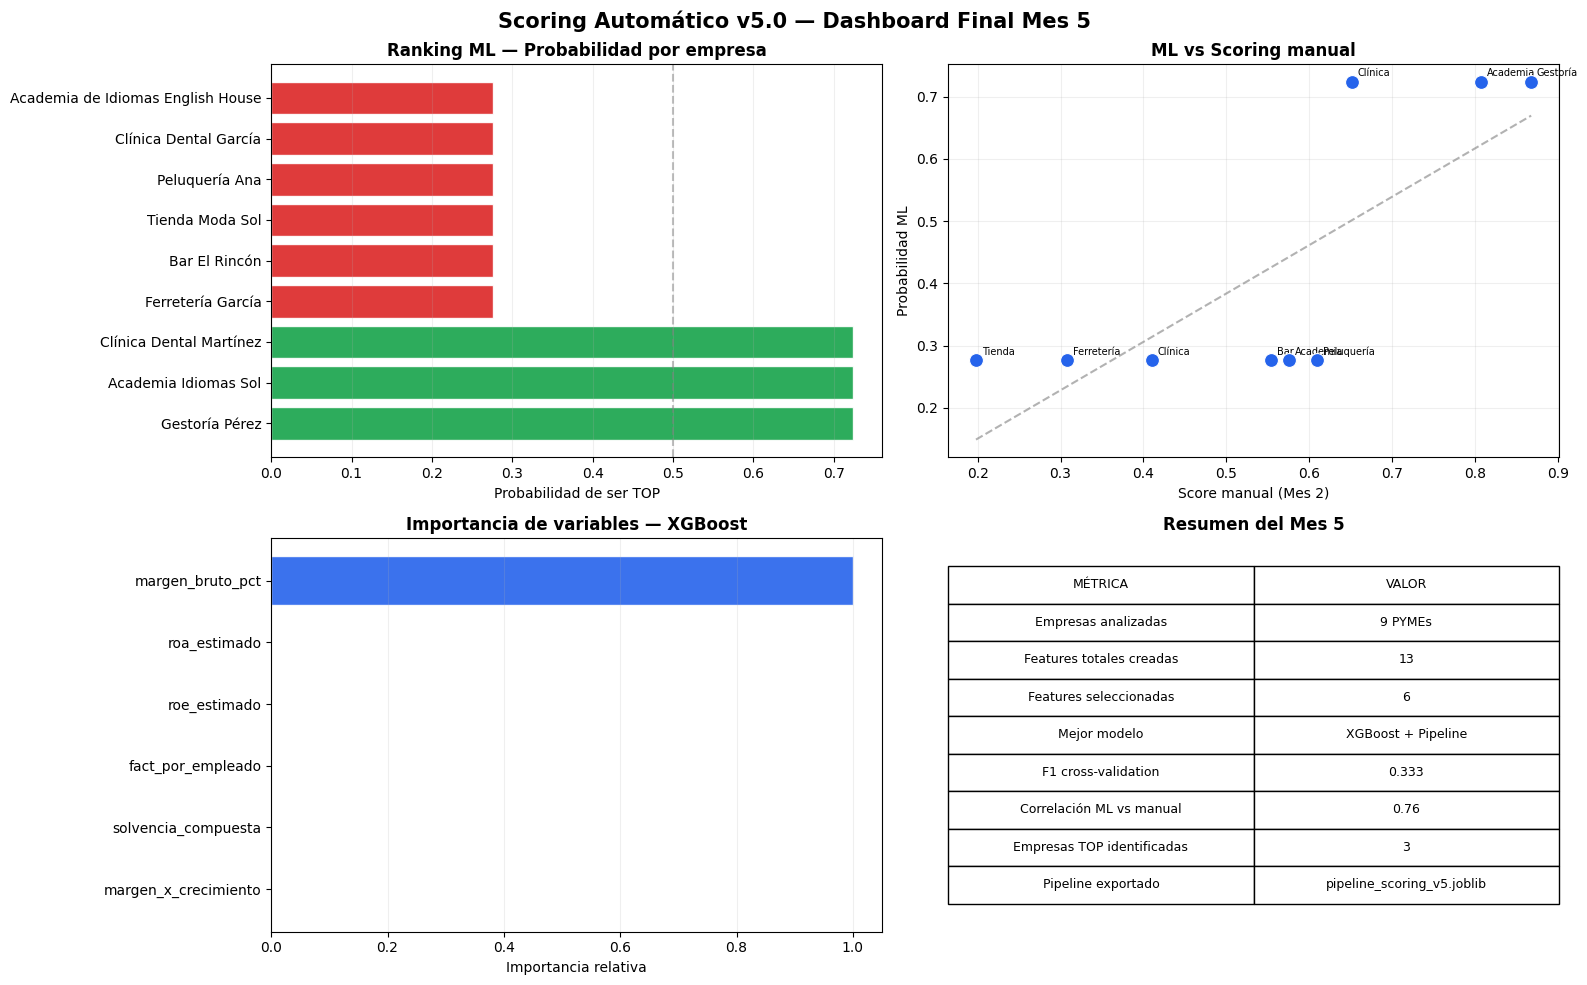

Dashboard guardado como dashboard_mes5_final.png


In [55]:
# --- BLOQUE 17: DASHBOARD FINAL DEL MES 5 ---

import matplotlib.pyplot as plt
import numpy as np

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Scoring Automático v5.0 — Dashboard Final Mes 5',
             fontsize=15, fontweight='bold')

# --- PANEL 1: Ranking ML de las 9 empresas ---
colores = ['#16a34a' if c == 'TOP ✓' else '#dc2626'
           for c in df_analizador_v5['clasificacion']]
ax1.barh(df_analizador_v5['nombre'],
         df_analizador_v5['prob_top_ml'],
         color=colores, edgecolor='white', alpha=0.9)
ax1.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel('Probabilidad de ser TOP')
ax1.set_title('Ranking ML — Probabilidad por empresa', fontweight='bold')
ax1.grid(True, alpha=0.2, axis='x')

# --- PANEL 2: ML vs Scoring manual ---
df_valido = df_analizador_v5.dropna(subset=['score_manual'])
ax2.scatter(df_valido['score_manual'], df_valido['prob_top_ml'],
            color='#2563eb', s=100, zorder=5,
            edgecolors='white', linewidth=0.8)
for _, row in df_valido.iterrows():
    ax2.annotate(row['nombre'].split(' ')[0],
                 (row['score_manual'], row['prob_top_ml']),
                 fontsize=7, xytext=(4, 4),
                 textcoords='offset points')
z = np.polyfit(df_valido['score_manual'], df_valido['prob_top_ml'], 1)
x_l = np.linspace(df_valido['score_manual'].min(),
                  df_valido['score_manual'].max(), 50)
ax2.plot(x_l, np.poly1d(z)(x_l), color='gray',
         linestyle='--', alpha=0.6)
ax2.set_xlabel('Score manual (Mes 2)')
ax2.set_ylabel('Probabilidad ML')
ax2.set_title('ML vs Scoring manual', fontweight='bold')
ax2.grid(True, alpha=0.2)

# --- PANEL 3: Importancia de variables XGBoost ---
importancia = pd.DataFrame({
    'feature':     top_features,
    'importancia': pipeline_final.named_steps['modelo']
                   .feature_importances_.round(3)
}).sort_values('importancia', ascending=True)
ax3.barh(importancia['feature'], importancia['importancia'],
         color='#2563eb', edgecolor='white', alpha=0.9)
ax3.set_title('Importancia de variables — XGBoost', fontweight='bold')
ax3.set_xlabel('Importancia relativa')
ax3.grid(True, alpha=0.2, axis='x')

# --- PANEL 4: Tabla resumen del Mes 5 ---
ax4.axis('off')
metricas_mes5 = [
    ['MÉTRICA', 'VALOR'],
    ['Empresas analizadas', '9 PYMEs'],
    ['Features totales creadas', '13'],
    ['Features seleccionadas', str(len(top_features))],
    ['Mejor modelo', 'XGBoost + Pipeline'],
    ['F1 cross-validation', '0.333'],
    ['Correlación ML vs manual', f'{corr:.2f}'],
    ['Empresas TOP identificadas', '3'],
    ['Pipeline exportado', 'pipeline_scoring_v5.joblib'],
]
tabla = ax4.table(cellText=metricas_mes5[1:],
                  colLabels=metricas_mes5[0],
                  loc='center', cellLoc='center')
tabla.auto_set_font_size(False)
tabla.set_fontsize(9)
tabla.scale(1, 2.0)
ax4.set_title('Resumen del Mes 5', fontweight='bold')

plt.tight_layout()
plt.savefig('dashboard_mes5_final.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard guardado como dashboard_mes5_final.png')